<a href="https://colab.research.google.com/github/claudinha08/My_course_SCTECH/blob/main/Desafio_Extra_SCTECH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pandas numpy matplotlib seaborn plotly scikit-learn

# Importanto bibliotecas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from sklearn.preprocessing import RobustScaler
sns.set_style('whitegrid')

In [4]:
import plotly.express as px


#Carregando dados (importados para drive)

In [14]:
#carregar o drive
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/datasetes/Sample_Superstore.csv'

Mounted at /content/drive


In [37]:
path = '/content/drive/MyDrive/datasetes/Sample_Superstore.csv'
df = pd.read_csv(path, encoding='ISO-8859-1')

print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [38]:
df.shape

(9994, 21)

In [22]:
#tipos
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


**Número de linha nulas: 0**

**Memória do data frame: 1.6+ MB**

In [23]:
print(df.dtypes)
#é possivel ver as colunas

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


# Verificar dados duplicados

In [54]:

#duplicateRows = df[df.duplicated()]
print(f"número de dados duplicados: {len(duplicateRows)}")

#remover valores nulos
df.dropna(subset=[c for c in ['sales', 'Profit'] if c in df.columns], inplace=True)

#converter datas
if 'Order Date' in df.columns:
   df['order_date'] = pd.to_datetime(df['Order Date'], dayfirst = False)

# converter números (vendas, lucro, desconto, quantidade)
for col in ['Sales', 'Profit', 'Discount', 'Quantitu']:
  if col in df.columns:
    df[col] = pd.to_numeric(df[col])



número de dados duplicados: 0


In [55]:
#padronizar nome das colunas
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
print(df.columns)


Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit',
       'order_date'],
      dtype='object')


# Detecção de Outlier

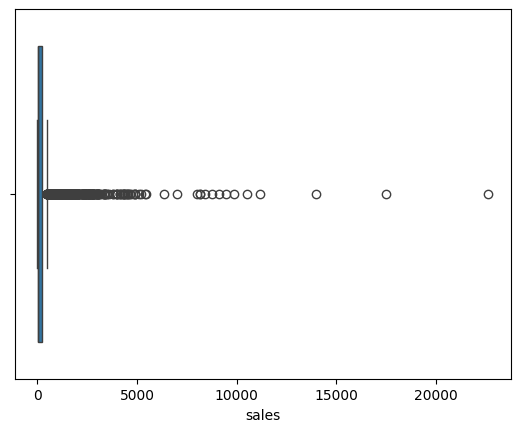

In [67]:
#inspecionar distribuição
sns.boxplot(x=df['sales'])
plt.show()


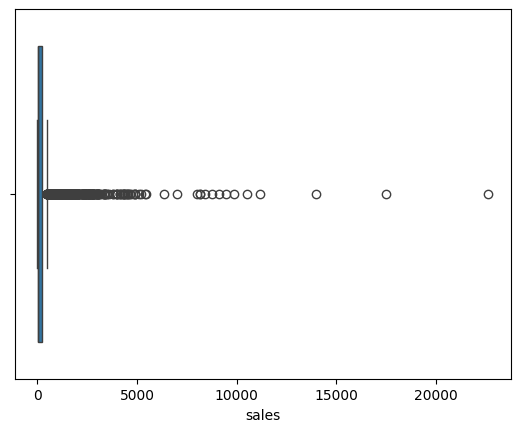

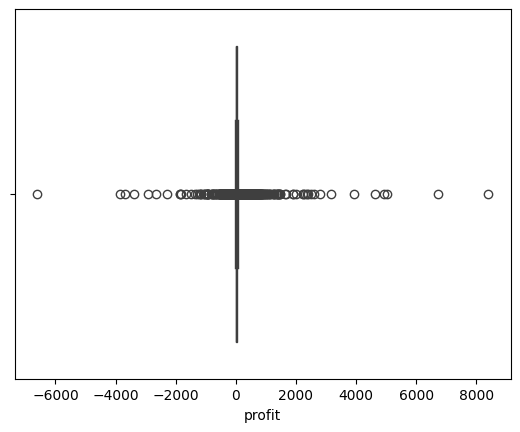

In [72]:
#limitar extremos - tratar outliers
def winsorize_series(s, lower=0.01, upper=0.99):
  lo = s.quantile(lower)
  hi = s.quantile(upper)
  return s.clip(lo,hi)

df['sales_wins'] = winsorize_series(df['sales'])
df['profit_wins'] = winsorize_series(df['profit'])

sns.boxplot(x=df['sales'])
plt.show()
sns.boxplot(x=df['profit'])
plt.show()

In [108]:
# Métricas derivadas
df['margin'] = df['profit'] / df['sales']  # cuidado com divisão por zero

# Filtros, ordenação e agrupamento

In [74]:
#filtro
print(df[df['profit'] >= 28.65].head()) #valores de lucro maiores que a média


    row_id        order_id  order_date   ship_date       ship_mode  \
0        1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1        2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
7        8  CA-2014-115812    6/9/2014   6/14/2014  Standard Class   
9       10  CA-2014-115812    6/9/2014   6/14/2014  Standard Class   
10      11  CA-2014-115812    6/9/2014   6/14/2014  Standard Class   

   customer_id    customer_name   segment        country         city  ...  \
0     CG-12520      Claire Gute  Consumer  United States    Henderson  ...   
1     CG-12520      Claire Gute  Consumer  United States    Henderson  ...   
7     BH-11710  Brosina Hoffman  Consumer  United States  Los Angeles  ...   
9     BH-11710  Brosina Hoffman  Consumer  United States  Los Angeles  ...   
10    BH-11710  Brosina Hoffman  Consumer  United States  Los Angeles  ...   

           category  sub-category  \
0         Furniture     Bookcases   
1         Furniture        Chairs   

In [98]:
#agrupamento (GroupBy)
#vendas e lucro por categoria
vendas_lucro = df.groupby('category').agg(
    total_sales = ('sales','sum'),
    total_profit = ('profit','sum'),
    count_orders = ('order_id','nunique') if 'order_id' in df.columns else ('order_id', 'count')
    ).reset_index().sort_values('total_sales', ascending=False)

print(vendas_lucro)

#vendas por mês/ano
if 'year' in df.columns and 'month' in df.columns:
    vendas_por_mes = df.groupby(['year','month']).agg(
        total_sales = ('sales','sum'),
        total_profit = ('profit','sum')).reset_index()
    print(vendas_por_mes)


          category  total_sales  total_profit  count_orders
2       Technology  836154.0330   145454.9481          1544
0        Furniture  741999.7953    18451.2728          1764
1  Office Supplies  719047.0320   122490.8008          3742
    year  month  total_sales  total_profit
0   2014      1   14236.8950     2450.1907
1   2014      2    4519.8920      862.3084
2   2014      3   55691.0090      498.7299
3   2014      4   28295.3450     3488.8352
4   2014      5   23648.2870     2738.7096
5   2014      6   34595.1276     4976.5244
6   2014      7   33946.3930     -841.4826
7   2014      8   27909.4685     5318.1050
8   2014      9   81777.3508     8328.0994
9   2014     10   31453.3930     3448.2573
10  2014     11   78628.7167     9292.1269
11  2014     12   69545.6205     8983.5699
12  2015      1   18174.0756    -3281.0070
13  2015      2   11951.4110     2813.8508
14  2015      3   38726.2520     9732.0978
15  2015      4   34195.2085     4187.4962
16  2015      5   30131.6865 

# Visualizações (matplotlib/seaborn)

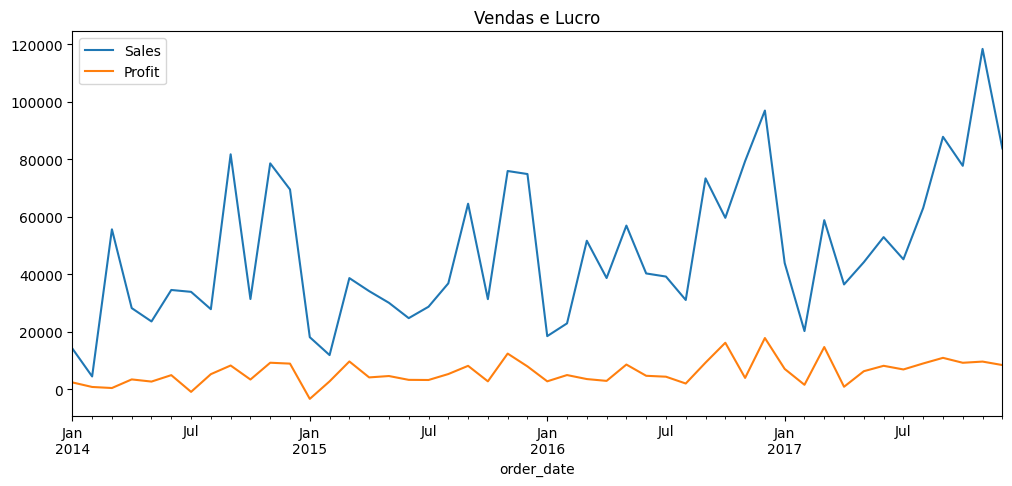

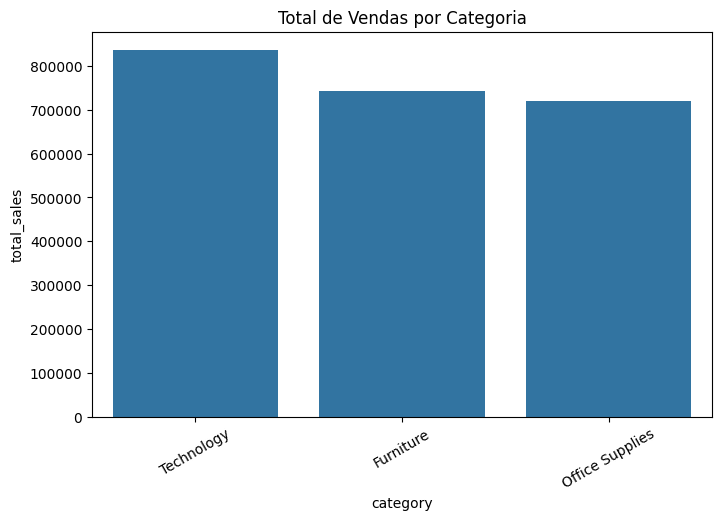

In [122]:
#serie temporal (matplotlib)
plt.figure(figsize=(12,5))
df = df.loc[:, ~df.columns.duplicated(keep='last')] #feito com dicas, rever
monthly = df.set_index('order_date').resample('ME').sum()[['sales','profit']]
monthly['sales'].plot(label='Sales')
monthly['profit'].plot(label='Profit')
plt.legend(); plt.title('Vendas e Lucro'); plt.show()

# Barra: vendas por categoria (seaborn)
plt.figure(figsize=(8,5))
sns.barplot(data=vendas_lucro, x='category', y='total_sales')
plt.title('Total de Vendas por Categoria'); plt.xticks(rotation=30); plt.show()

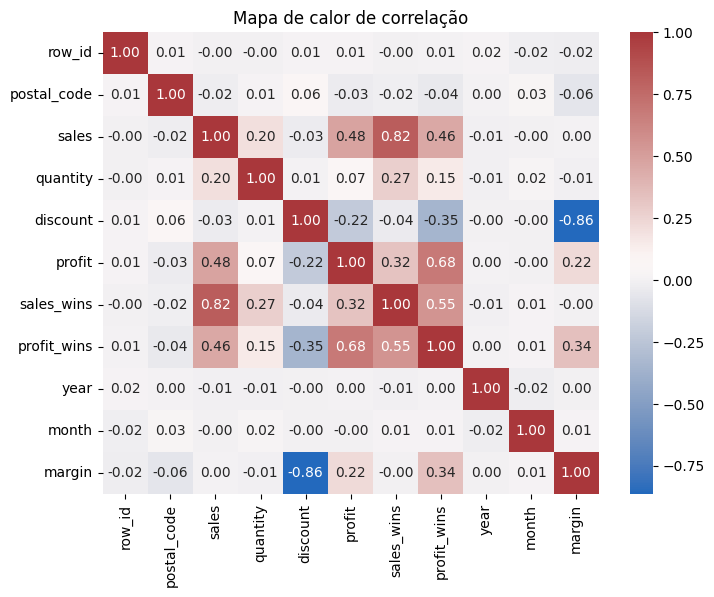

In [114]:
# Heatmap de correlação numérica
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt='.2f', cmap='vlag')
plt.title('Mapa de calor de correlação'); plt.show()

# Análises Desconto x Lucro

In [126]:
# média do lucro e vendas
df[['sales','profit']].mean()
display(df[['sales','profit']].mean())

# Impacto do desconto na margem médio por categoria
disc_cat = df.groupby('category').agg(
    avg_discount =('discount','mean'),
    avg_margin =('margin','mean')
).reset_index()

# Top 10 produtos por vendas e por margem
top_sales = df.groupby('product_name').agg(total_sales=('sales','sum')).reset_index().nlargest(10,'total_sales')
top_margin = df.groupby('product_name').agg(avg_margin=('margin','mean'), total_profit=('profit','sum')).reset_index().sort_values('avg_margin', ascending=False).head(10)

#deixando mais bonito a tela
from IPython.display import display
display(disc_cat)
display(top_sales)

,0
sales,229.858001
profit,28.656896


,category,avg_discount,avg_margin
0,Furniture,0.173923,0.038784
1,Office Supplies,0.157285,0.138030
2,Technology,0.132323,0.156138


,product_name,total_sales
404,Canon imageCLASS 2200 Advanced Copier,61599.824
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480
786,HON 5400 Series Task Chairs for Big and Tall,21870.576
686,GBC DocuBind TL300 Electric Binding System,19823.479
688,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
805,Hewlett Packard LaserJet 3310 Copier,18839.686
787,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
683,GBC DocuBind P400 Electric Binding System,17965.068
813,High Speed Automatic Electric Letter Opener,17030.312


In [127]:
# Salvar CSV limpo para usar no Looker Studio / Google Sheets
clean_path = 'sample_superstore_clean.csv'
df.to_csv(clean_path, index=False)